# Environment Setup

## Load Models

In [1]:
from xgboost import XGBClassifier
import json
import joblib

In [2]:
# xgboost model
model_xgb = XGBClassifier()
model_xgb.load_model("model/xgb_v2_model.json")
with open("model/xgb_v2_meta.json", "r", encoding="utf-8") as f:
    meta_xgb = json.load(f)

# logistic regression model
model_logreg = joblib.load("model/logreg_model.joblib")
with open("model/logreg_meta.json", "r", encoding="utf-8") as f:
    meta_logreg = json.load(f)

# random forest model
model_rf = joblib.load("model/rf_model.joblib")
with open("model/rf_meta.json", "r", encoding="utf-8") as f:
    meta_rf = json.load(f)

## Load Data

In [3]:
import pandas as pd
df_test = pd.read_csv("https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/test.csv")
df_train = pd.read_csv("https://raw.githubusercontent.com/kup-kup/telemarketing-prediction/refs/heads/main/processed-data/train.csv")

X_test = df_test.drop(columns=["y"])
X_test = X_test[meta_rf["feature_names"]]
y_test = df_test["y"]

X_train = df_train.drop(columns=["y"])
X_train = X_train[meta_rf["feature_names"]]
y_train = df_train["y"]

In [4]:
from sklearn.model_selection import train_test_split
df_raw = pd.read_csv('data/bank-additional-full.csv', sep=';')
df_train_raw, df_test_raw = train_test_split(df_raw, test_size=0.2, random_state=42)

## Quick Model Check

In [5]:
from sklearn.metrics import classification_report

y_pred_rf = model_rf.predict(X_test)
print("========== Random Forest Model ==========")
print(classification_report(y_test, y_pred_rf))
print()

y_pred_lr = model_logreg.predict(X_test)
print("========== Logistic Regression Model ==========")
print(classification_report(y_test, y_pred_lr))
print()

y_pred_xgb = model_xgb.predict(X_test)
print("========== XGBoost Model ==========")
print(classification_report(y_test, y_pred_xgb))

========== Random Forest Model ==========
              precision    recall  f1-score   support

       False       0.94      0.93      0.93      7310
        True       0.49      0.56      0.53       928

    accuracy                           0.89      8238
   macro avg       0.72      0.75      0.73      8238
weighted avg       0.89      0.89      0.89      8238


========== Logistic Regression Model ==========
              precision    recall  f1-score   support

       False       0.91      0.99      0.95      7310
        True       0.68      0.18      0.29       928

    accuracy                           0.90      8238
   macro avg       0.79      0.59      0.62      8238
weighted avg       0.88      0.90      0.87      8238


========== XGBoost Model ==========
              precision    recall  f1-score   support

       False       0.95      0.91      0.93      7310
        True       0.46      0.62      0.53       928

    accuracy                           0.88      8238


# Survial Analysis

- fit Kaplan Meier Estimator to estimate the survival function for the entire population
- fit Cox Proportional Hazards Model to understand the impact of features on the hazard function

## Kaplan Meier Estimator

In [6]:
X_train['campaign'].sort_values().unique()

array([-0.56702251, -0.20368791,  0.15964669,  0.52298128,  0.88631588,
        1.24965047,  1.61298507,  1.97631966,  2.33965426,  2.70298885,
        3.06632345,  3.42965804,  3.79299264,  4.15632724,  4.51966183,
        4.88299643,  5.24633102,  5.60966562,  5.97300021,  6.33633481,
        6.6996694 ,  7.063004  ,  7.4263386 ,  7.78967319,  8.15300779,
        8.51634238,  8.87967698,  9.24301157,  9.60634617,  9.96968076,
       10.33301536, 10.69634995, 11.05968455, 11.42301915, 11.78635374,
       12.51302293, 13.60302672, 14.32969591, 14.69303051, 19.41638025])

In [7]:
X_train_survival = X_train.copy()
unique_campaigns = X_train_survival['campaign'].sort_values().unique()
mapper = {campaign: i+1 for i, campaign in enumerate(unique_campaigns)}
X_train_survival['campaign'] = X_train_survival['campaign'].map(mapper)
X_train_survival['campaign'].value_counts()

campaign
1     14121
2      8469
3      4300
4      2116
5      1255
6       773
7       493
8       329
9       220
10      187
11      142
12       92
13       74
14       52
17       51
15       45
16       42
18       27
20       22
21       20
19       16
22       13
24       12
23       12
27        9
25        8
29        7
31        7
26        7
28        6
30        6
35        4
33        3
39        2
38        2
32        2
36        1
34        1
37        1
40        1
Name: count, dtype: int64

          Cumulative_Conversion_Rate  Marginal_Gain
timeline                                           
0.0                         0.000000       0.000000
1.0                         0.055296       0.055296
2.0                         0.104566       0.049270
3.0                         0.144670       0.040104
4.0                         0.173463       0.028793
5.0                         0.191905       0.018442
6.0                         0.210838       0.018933
7.0                         0.224842       0.014004
8.0                         0.231923       0.007082
9.0                         0.240348       0.008425


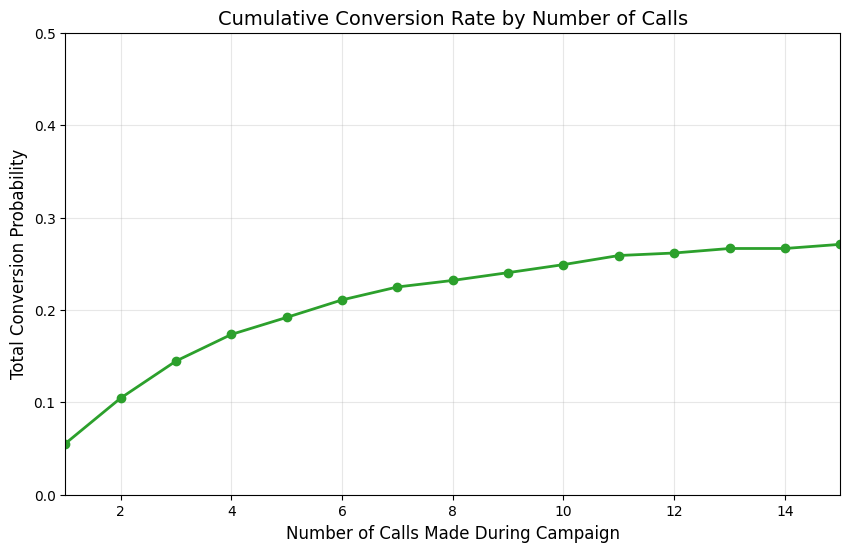

In [8]:
"""
Understanding the general impact of number of calls on conversion probability using Kaplan Meier Estimator
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# descale the campaign feature to get the original number of calls
X_train_survival = X_train.copy()
unique_campaigns = X_train_survival['campaign'].sort_values().unique()
mapper = {campaign: i+1 for i, campaign in enumerate(unique_campaigns)}
X_train_survival['campaign'] = X_train_survival['campaign'].map(mapper)

kmf = KaplanMeierFitter()
kmf.fit(durations=X_train_survival['campaign'], event_observed=y_train)

# calculate cumulative conversion rate and marginal gain per call
cumulative_conversion = 1 - kmf.survival_function_
cumulative_conversion.columns = ['Cumulative_Conversion_Rate']

cumulative_conversion['Marginal_Gain'] = cumulative_conversion['Cumulative_Conversion_Rate'].diff()
cumulative_conversion['Marginal_Gain'] = cumulative_conversion['Marginal_Gain'].fillna(cumulative_conversion['Cumulative_Conversion_Rate'])

# display
print(cumulative_conversion.head(10))
plt.figure(figsize=(10, 6))
plt.plot(cumulative_conversion.index, cumulative_conversion['Cumulative_Conversion_Rate'], 
         marker='o', linestyle='-', color='#2ca02c', linewidth=2)

plt.title('Cumulative Conversion Rate by Number of Calls', fontsize=14)
plt.xlabel('Number of Calls Made During Campaign', fontsize=12)
plt.ylabel('Total Conversion Probability', fontsize=12)
plt.ylim(0, 0.5)
plt.xlim(1, 15)
plt.grid(True, alpha=0.3)
plt.show()

## Cox Proportional Hazards Model

c:\Users\konkanok\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lifelines\utils\__init__.py:1100: ConvergenceWarning: Column(s) ['default_yes'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


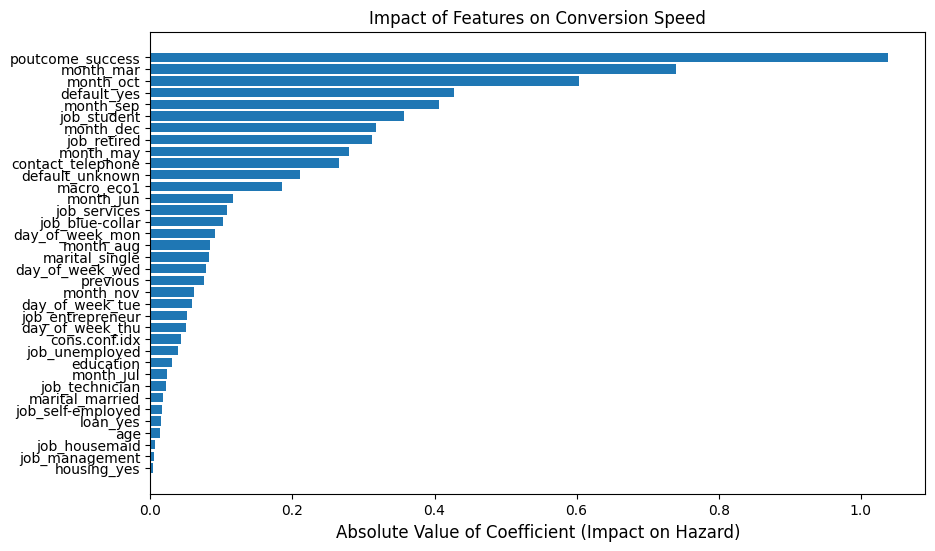

In [9]:
"""
Fit Cox Proportional Hazards Model to 
- understand the impact each of the features on the hazard function
- predict the optimal number of calls for different customer profiles
"""

import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# add regularization for numerical stability
cph = CoxPHFitter(penalizer=0.1)

# fit model
df_train_survival = pd.concat([X_train_survival, y_train], axis=1)
cph.fit(df_train_survival, duration_col='campaign', event_col='y')

impact = cph.summary['coef'].abs().sort_values(ascending=True)

# display the impact of features on the hazard function
plt.figure(figsize=(10, 6))
plt.barh(impact.index, impact.values, color='#1f77b4')
plt.xlabel('Absolute Value of Coefficient (Impact on Hazard)', fontsize=12)
plt.title("Impact of Features on Conversion Speed")
plt.show()

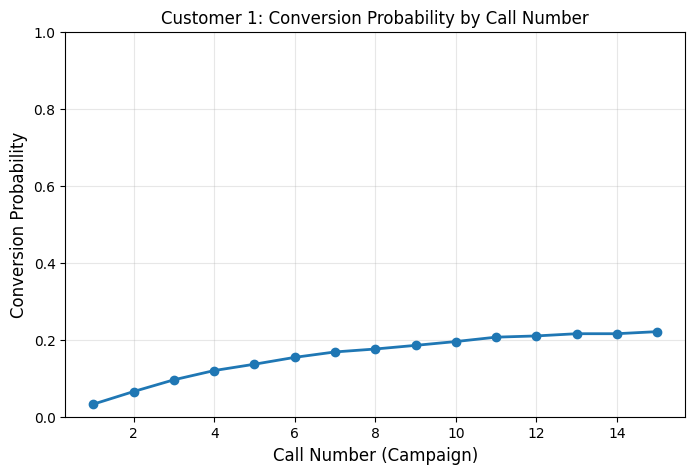

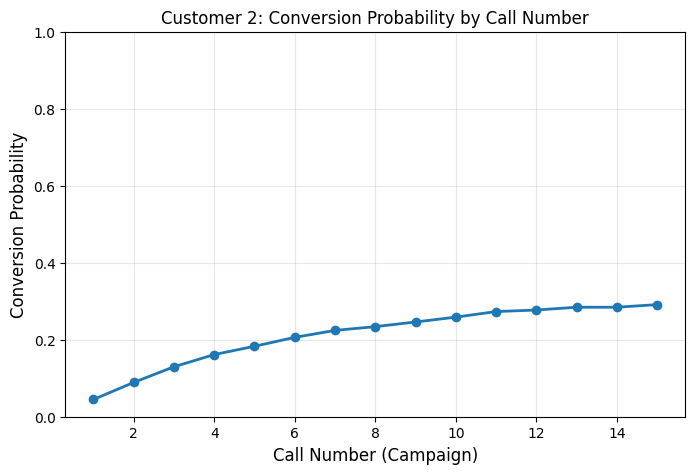

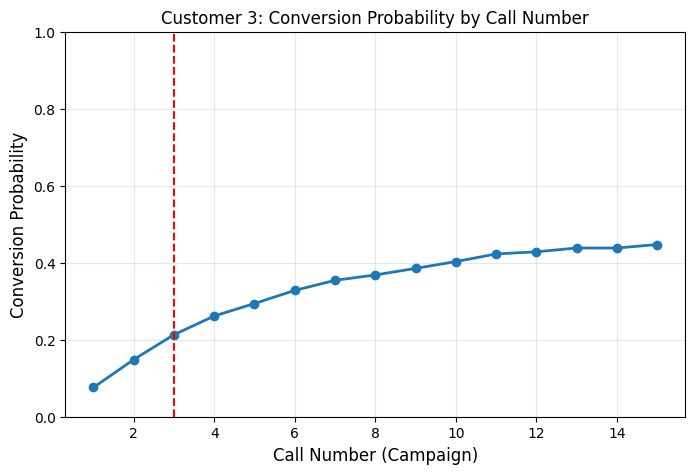

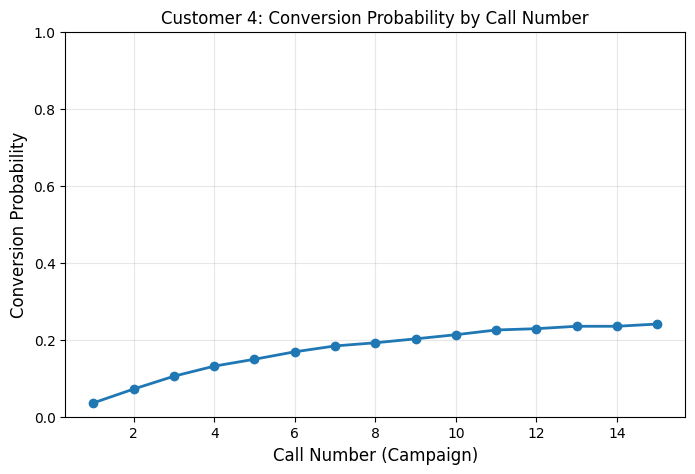

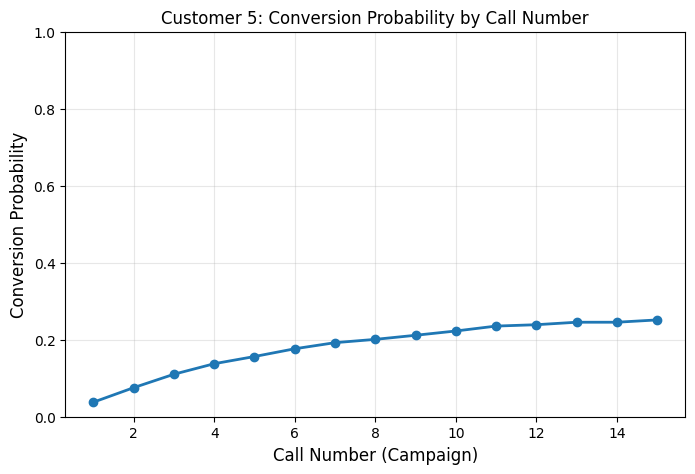

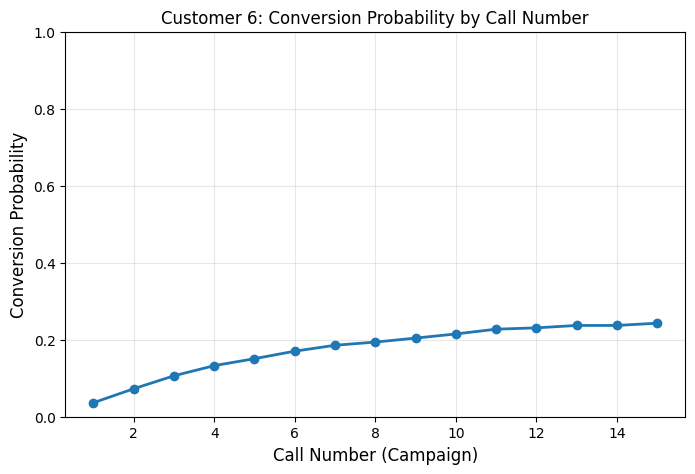

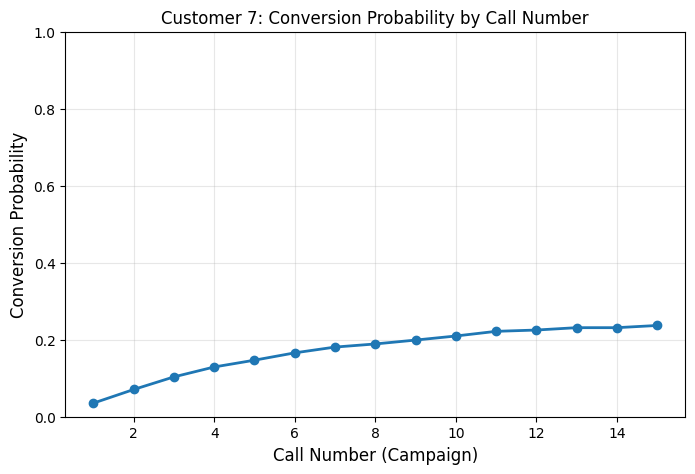

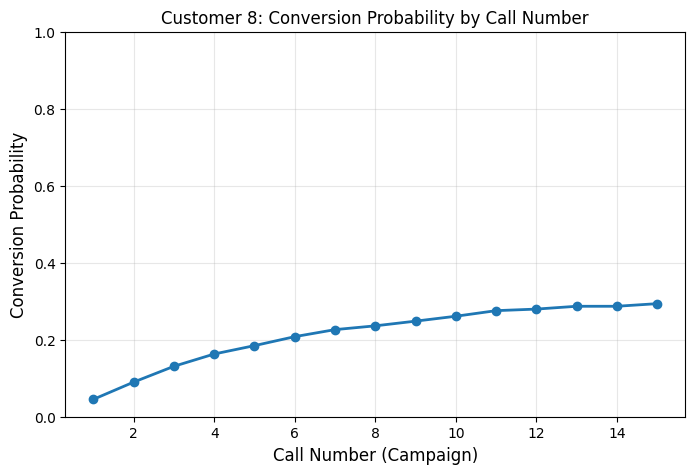

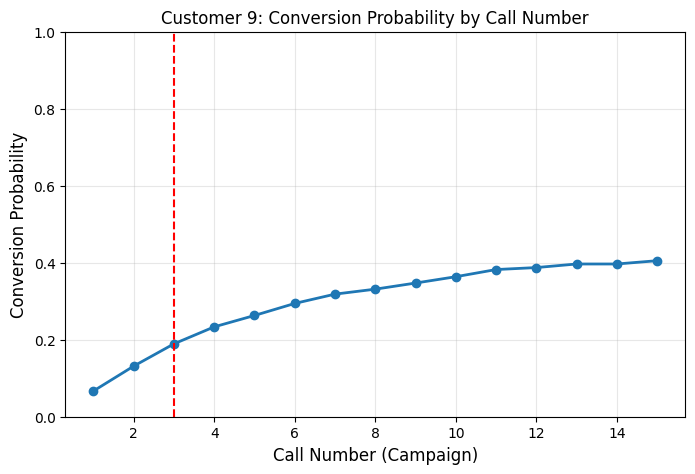

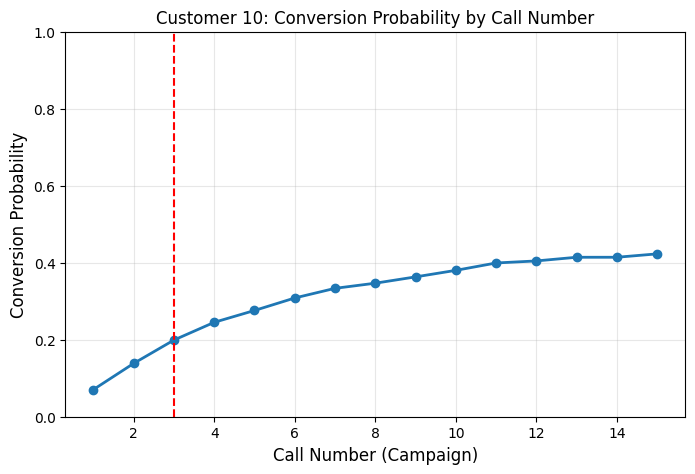

In [ ]:
from lib import tp_prime

# sample datapoints for analysis
n_samples = 10
sample_raw = df_test_raw.sample(n=n_samples, random_state=42)

for i in range(n_samples):
    sample = tp_prime(sample_raw.iloc[[i]])  # keep as DataFrame
    survival_curve = cph.predict_survival_function(sample, times=np.arange(1, 16, 1))
    conversion_curve = (1 - survival_curve).rename(
        columns={survival_curve.columns[0]: "Conversion_Probability"}
    )
    conversion_curve['Marginal_Gain'] = conversion_curve['Conversion_Probability'].diff().fillna(
        conversion_curve['Conversion_Probability']
    )

    # define your business threshold <---- VERY IMPORTANT
    # Stop calling if the next call adds less than a 5% chance of conversion
    threshold = 0.05

    # find the optimal cutoff point
    optimal_cutoff = conversion_curve[conversion_curve['Marginal_Gain'] < threshold].index[0] - 1

    plt.figure(figsize=(8, 5))
    plt.plot(conversion_curve.index, conversion_curve['Conversion_Probability'], 
             marker='o', linestyle='-', color='#1f77b4', linewidth=2)
    if optimal_cutoff >= 1:
        plt.axvline(x=optimal_cutoff, color='red', linestyle='--', label=f'Optimal Call Limit: {optimal_cutoff}')
    plt.title(f'Customer {i+1}: Conversion Probability by Call Number')
    plt.xlabel('Call Number (Campaign)', fontsize=12)
    plt.ylabel('Conversion Probability', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.show()

# Macroeconomics Sensitivity Analysis

- analyze how changes in macroeconomic indicators (e.g., interest rates, unemployment rates) affect the model's predictions
- perform sensitivity analysis by varying these indicators and observing the impact on the predicted probabilities of subscription

## Individual Indicator

In [11]:
# sample datapoints for analysis
n_samples = 50
sample_raw = df_test_raw.sample(n=n_samples, random_state=1)

In [12]:
import numpy as np
from lib import *

# set range of macroeconomic indicators for analysis
n_ranges = 10
macroeconomic_indicators = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
ranges = {x: np.linspace(df_raw[x].quantile(0.25), df_raw[x].quantile(0.75), n_ranges) for x in macroeconomic_indicators}

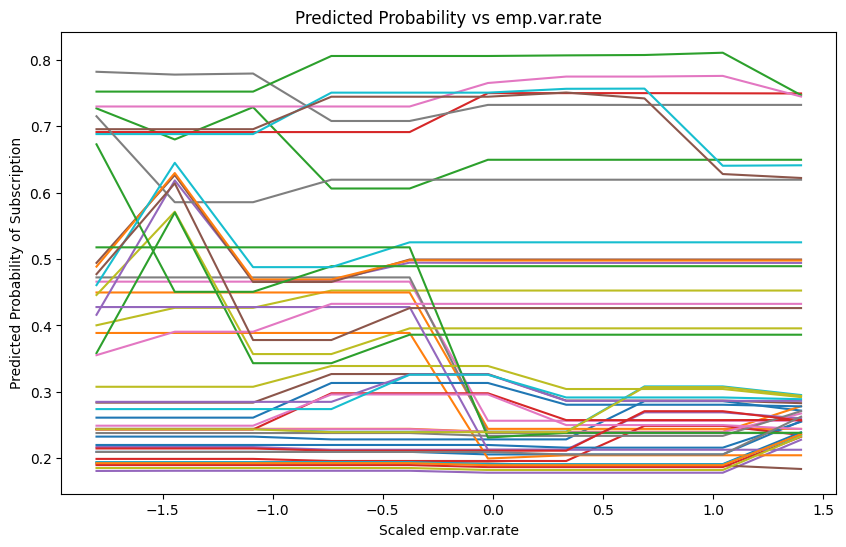

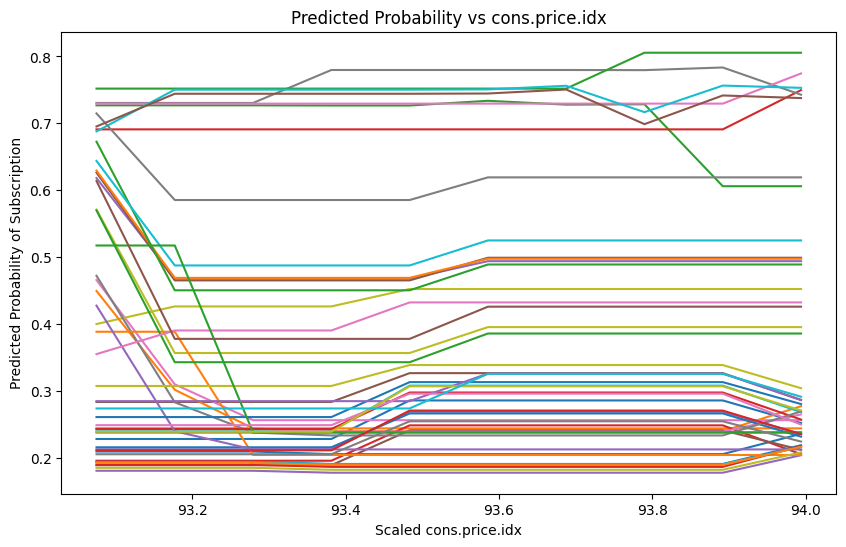

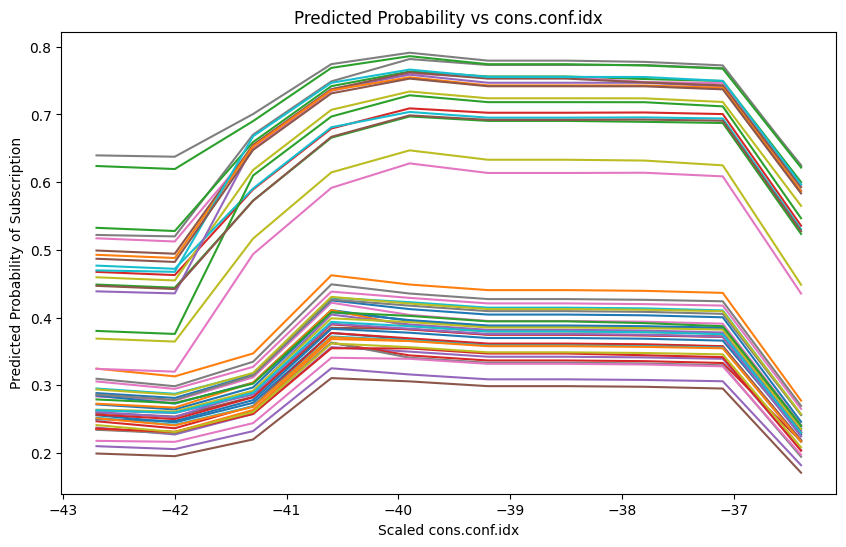

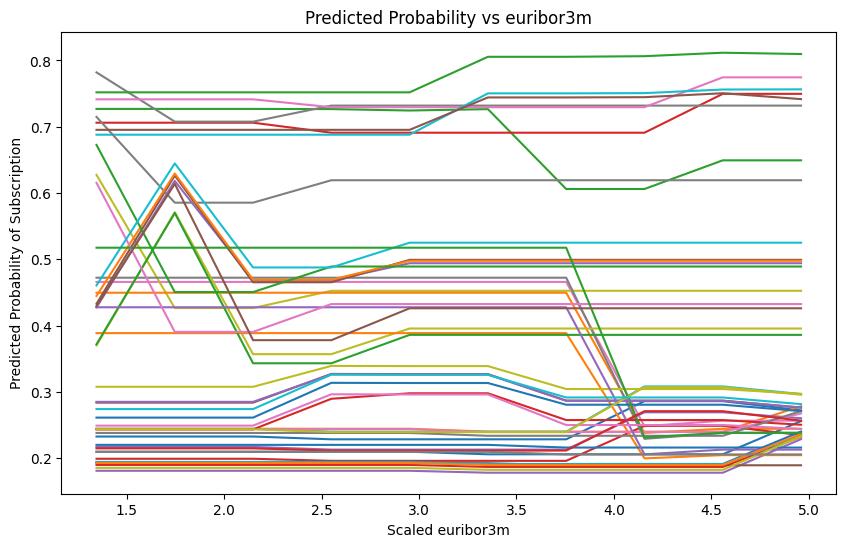

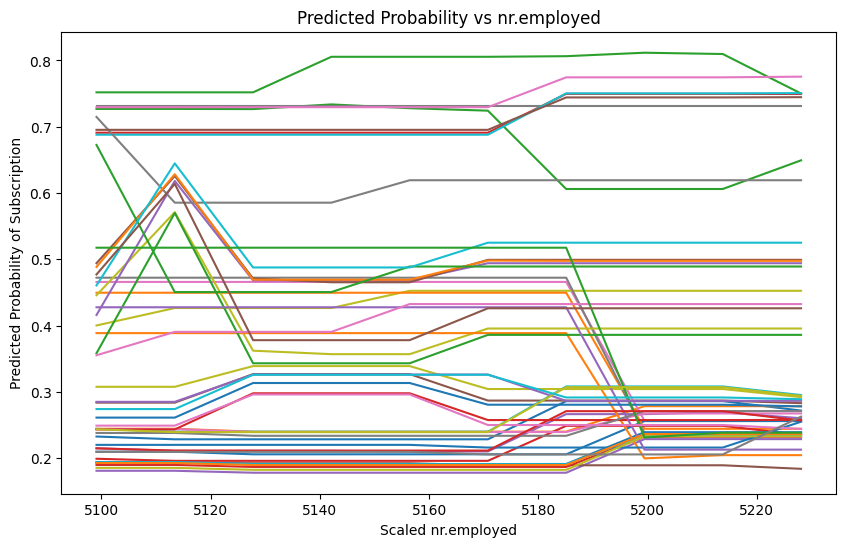

In [13]:
# analyze model predictions across macroeconomic indicator ranges
import matplotlib.pyplot as plt
for indicator in macroeconomic_indicators:
    plt.figure(figsize=(10, 6))
    plt.title(f"Predicted Probability vs {indicator}")
    plt.xlabel(f"Scaled {indicator}")
    plt.ylabel("Predicted Probability of Subscription")

    for i in range(n_samples):
        sample = sample_raw.iloc[i]
        sample_repeated = pd.DataFrame([sample] * n_ranges, columns=sample_raw.columns)
        sample_repeated[indicator] = ranges[indicator]
        sample_repeated = tp_prime(sample_repeated)
        sample_repeated = sample_repeated[meta_rf["feature_names"]]
        pred_proba = model_xgb.predict_proba(sample_repeated)[:, 1]

        plt.plot(ranges[indicator], pred_proba, label=f"Sample {i+1}")

    plt.show()

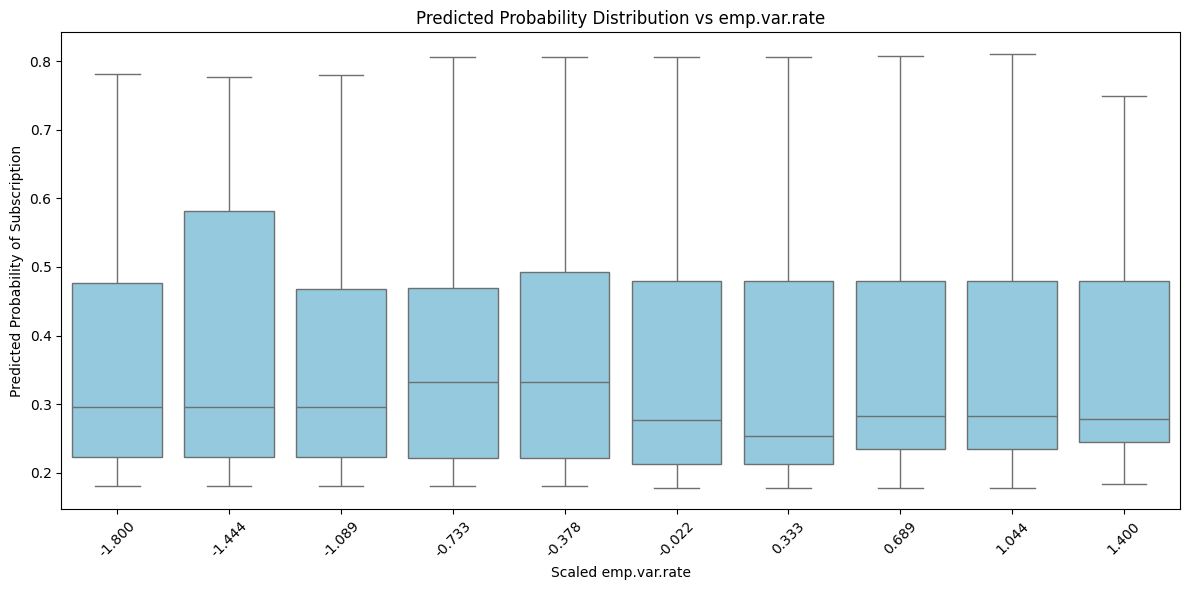

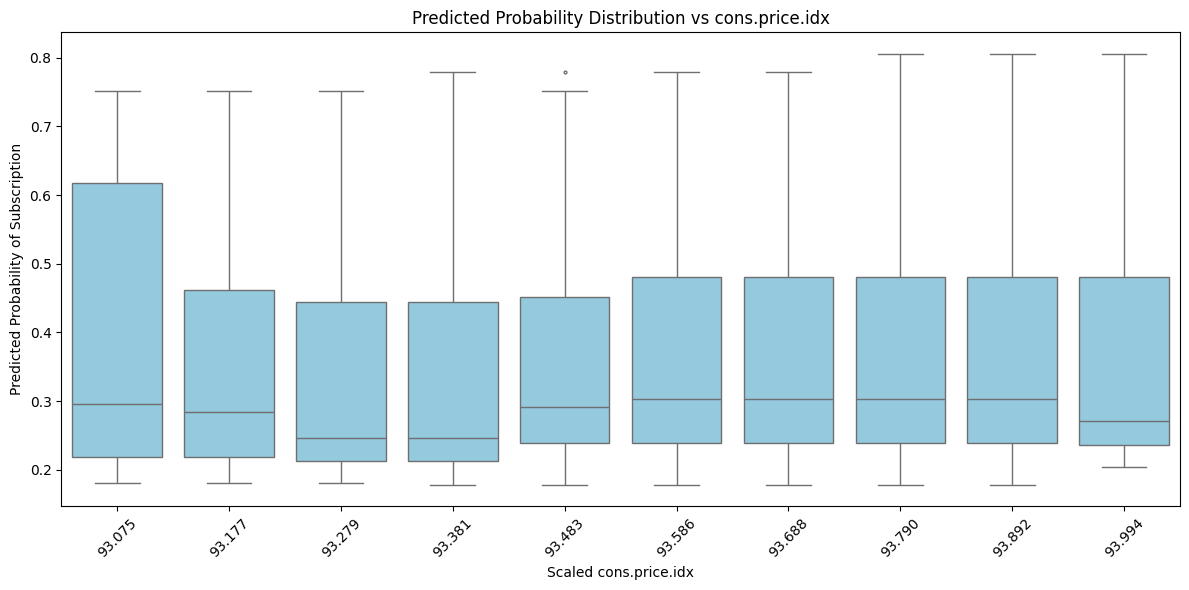

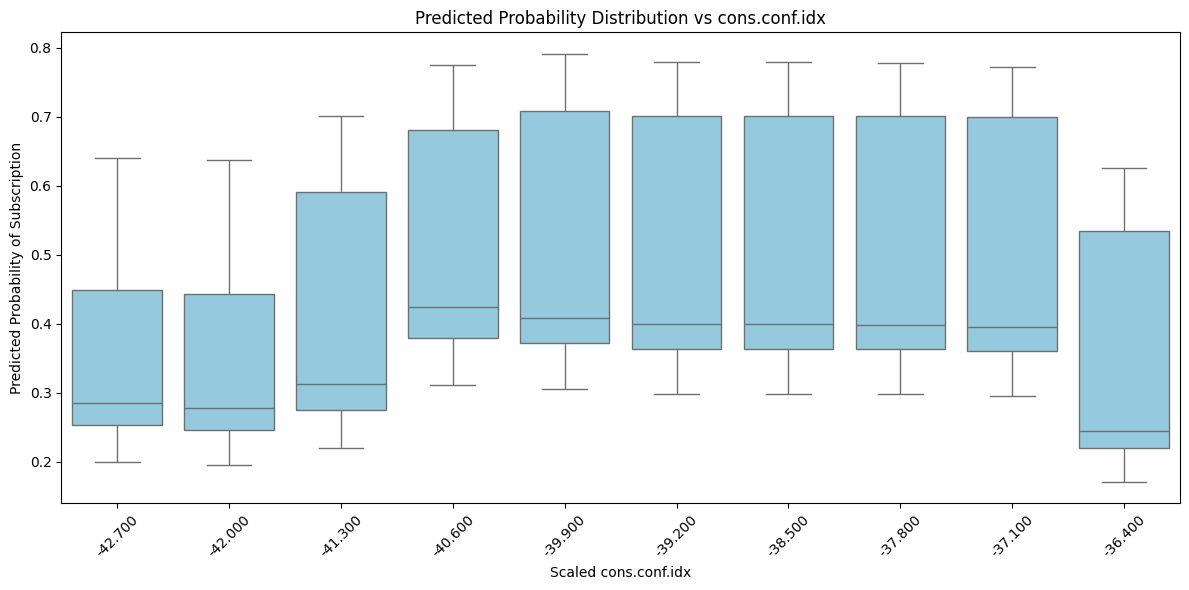

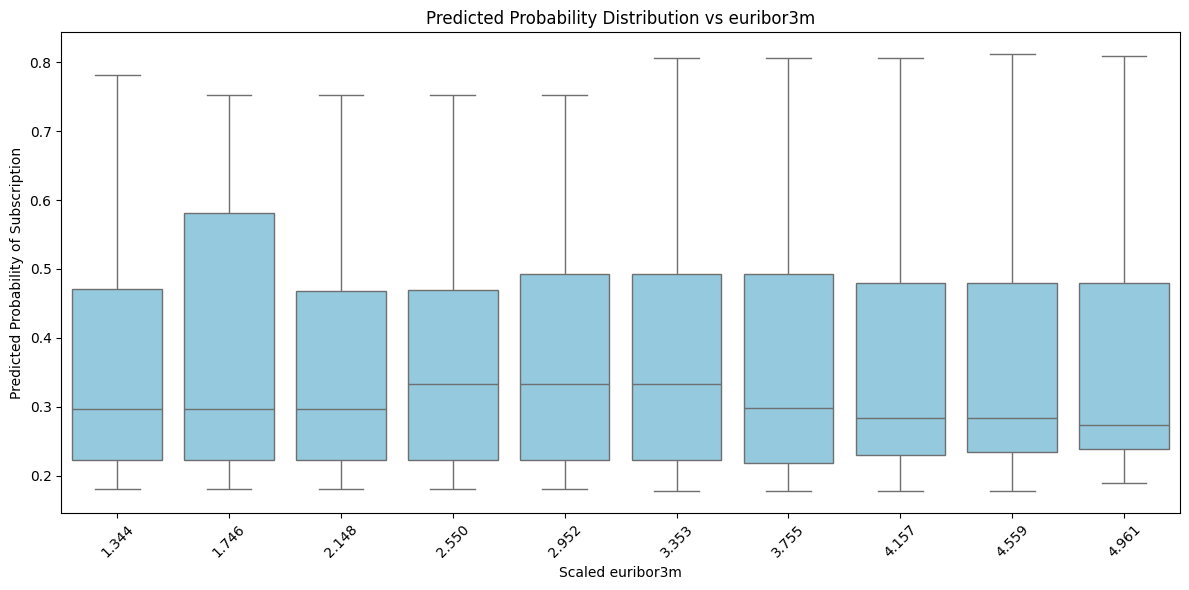

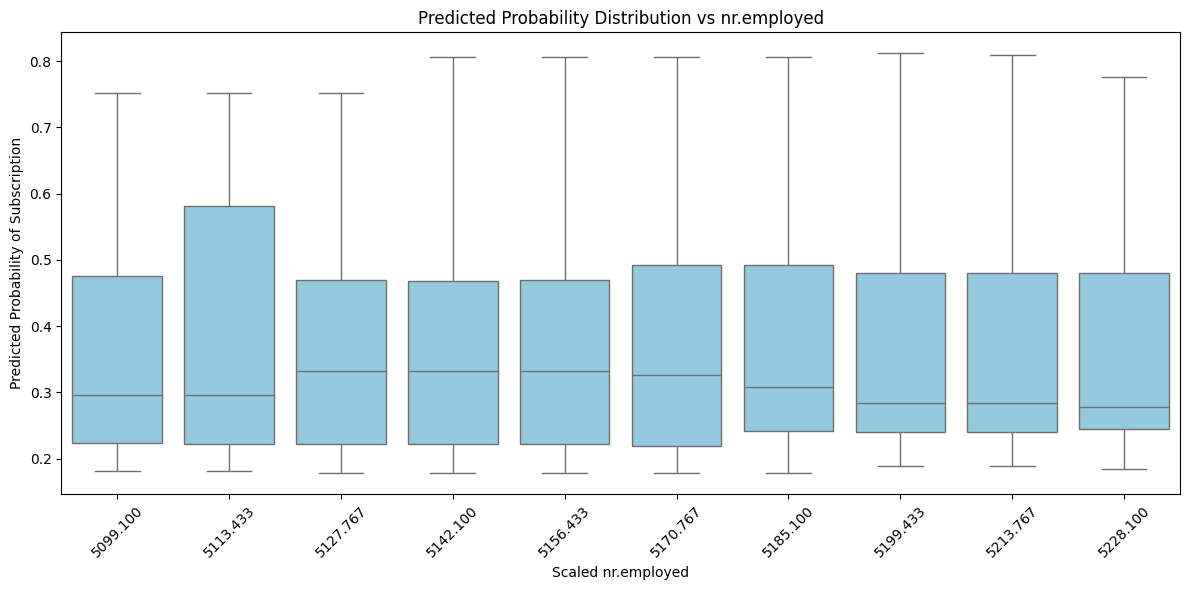

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

for indicator in macroeconomic_indicators:
    all_rows = []

    for i in range(n_samples):
        sample = sample_raw.iloc[i]
        sample_repeated = pd.DataFrame([sample] * n_ranges, columns=sample_raw.columns)
        sample_repeated[indicator] = ranges[indicator]

        sample_repeated = tp_prime(sample_repeated)
        sample_repeated = sample_repeated[meta_rf["feature_names"]]

        pred_proba = model_xgb.predict_proba(sample_repeated)[:, 1]

        all_rows.append(
            pd.DataFrame(
                {
                    "indicator_value": ranges[indicator],
                    "pred_proba": pred_proba,
                }))

    plot_df = pd.concat(all_rows, ignore_index=True)
    plot_df["indicator_label"] = plot_df["indicator_value"].map(lambda v: f"{v:.3f}")
    label_order = [f"{v:.3f}" for v in ranges[indicator]]

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=plot_df,
        x="indicator_label",
        y="pred_proba",
        order=label_order,
        color="skyblue",
        fliersize=2
    )
    plt.title(f"Predicted Probability Distribution vs {indicator}")
    plt.xlabel(f"Scaled {indicator}")
    plt.ylabel("Predicted Probability of Subscription")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## PCA-transformed Feature

In [15]:
# sample datapoints for analysis
n_samples = 50
sample_raw = X_test.sample(n=n_samples, random_state=42)

In [16]:
n_ranges = 10
arange = np.linspace(X_test['macro_eco1'].min(), X_test['macro_eco1'].max(), n_ranges)

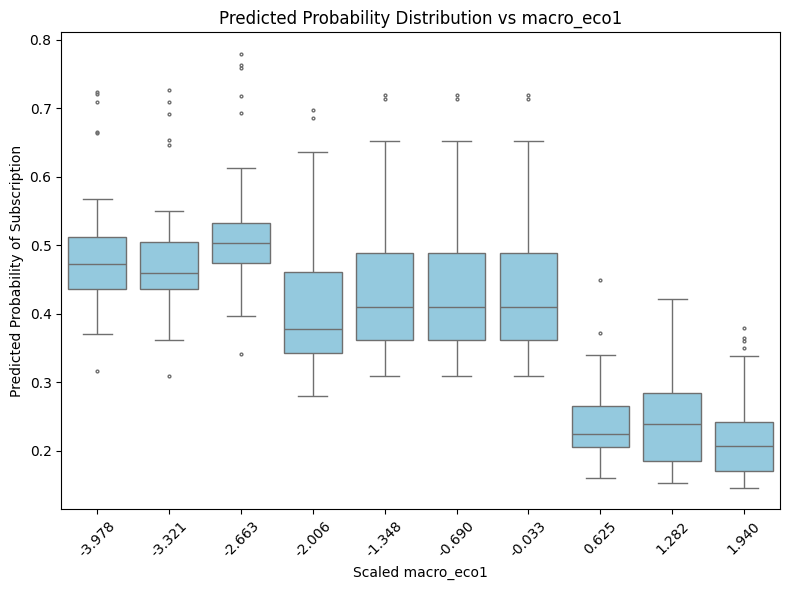

In [17]:
all_rows = []
for i in range(n_samples):
    sample = sample_raw.iloc[i]
    sample_repeated = pd.DataFrame([sample] * n_ranges, columns=sample_raw.columns)
    sample_repeated['macro_eco1'] = arange
    sample_repeated = sample_repeated[meta_rf["feature_names"]]

    pred_proba = model_xgb.predict_proba(sample_repeated)[:, 1]

    all_rows.append(
        pd.DataFrame(
            {
                "indicator_value": arange,
                "pred_proba": pred_proba,
            }))

plot_df = pd.concat(all_rows, ignore_index=True)
plot_df["indicator_label"] = plot_df["indicator_value"].map(lambda v: f"{v:.3f}")
label_order = [f"{v:.3f}" for v in arange]

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=plot_df,
    x="indicator_label",
    y="pred_proba",
    order=label_order,
    color="skyblue",
    fliersize=2
)
plt.title(f"Predicted Probability Distribution vs macro_eco1")
plt.xlabel(f"Scaled macro_eco1")
plt.ylabel("Predicted Probability of Subscription")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We can see the the PCA-transformed feature seems to indicate market conditions, with
- macro_eco1 < -2.5 indicating good market conditions
- macro_eco1 in [-2.5, 0] indicating normal conditions
- macro_eco1 > 0 indicating bad market conditions

### Simple Pipeline for Market Indicator

In [ ]:
def tp_transform_macro(indicator):
    """Transform a macroeconomic indicator value to the corresponding value in the PCA space used by the model.
    May have some error due to rounding, but should be close enough for interpretation purposes.
    indicator: array of shape (_, 4) containing the 4 macroeconomic indicators in the order of emp.var.rate, 
    cons.price.idx, euribor3m, nr.employed
    """
    mean = np.array([8.047e-2, 9.358e1, 3.618e0, 5.167e3])
    std = np.array([1.571e0, 5.792e-1, 1.736e0, 7.243e1])
    cpn = np.array([5.358e-1, 4.278e-1, 5.304e-1, 4.986e-1])
    return (indicator - mean) / std @ cpn

In [43]:
test_raw = df_train_raw.iloc[:10]

In [44]:
tp_transform_macro(test_raw[["emp.var.rate", "cons.price.idx", "euribor3m", "nr.employed"]])

12556    1.530310
35451   -2.341513
30592   -2.307904
17914    1.530615
3315     1.198181
29191   -2.157896
30549   -2.307904
6098     1.197265
6252     1.197265
13373    1.530921
dtype: float64

In [46]:
tp_prime(test_raw)['macro_eco1']

0    1.533845
1   -2.337809
2   -2.304200
3    1.534151
4    1.201748
5   -2.154180
6   -2.304200
7    1.200832
8    1.200832
9    1.534456
Name: macro_eco1, dtype: float64